## Configuration and Imports

In this section, we import the necessary libraries and define the configuration parameters for our experiment, including paths and hyperparameters.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add functions directory to path
sys.path.append(os.path.abspath("functions"))

from functions.dataset import COVIDCXNetDataset
from functions.train import train
from functions.evaluation import eval_on_metrics

# Constants
DATA_DIR = "E:/"
CSV_PATH = "E:/covidx/covidx_merged.csv"
SEEDS = [42, 123, 2024]
BATCH_SIZE = 32
EPOCHS = 5
LR = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
import os
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Data Loader Preparation

We prepare the data transformations and create the data loaders for the training, validation, and test splits using the `COVIDCXNetDataset`.

In [7]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Datasets
train_dataset = COVIDCXNetDataset(csv_file=CSV_PATH, root_dir=DATA_DIR, transform=transform, split="train")
val_dataset = COVIDCXNetDataset(csv_file=CSV_PATH, root_dir=DATA_DIR, transform=transform, split="val")
test_dataset = COVIDCXNetDataset(csv_file=CSV_PATH, root_dir=DATA_DIR, transform=transform, split="test")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

os.makedirs("logs", exist_ok=True)
os.makedirs("models", exist_ok=True)

Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911
Original samples: 8482
Valid AP/PA samples: 7143
Loaded 7143 samples for split 'test'
Class distribution: PA=3406, AP=3737


## Seed Comparison Experiment

We iterate through different random seeds, train a ResNet-18 model for each, and collect the final test metrics to analyze the impact of randomness.

In [8]:
results = []

for seed in SEEDS:
    print(f"\n{'='*20}\nRunning Experiment with Seed: {seed}\n{'='*20}")
    set_seed(seed)
    
    # Initialize Model
    model = models.resnet18(weights='DEFAULT')
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    # Train
    save_path = f'models/best_model_seed_{seed}.pth'
    log_path = f'logs/training_seed_{seed}.log'
    
    metrics = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        save_path=save_path,
        num_epochs=EPOCHS,
        patience=3,
        log_path=log_path
    )
    
    # Evaluate on Test Set
    print(f'Evaluating Seed {seed} on Test Set...')
    model.load_state_dict(torch.load(save_path))
    
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(lbls.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    from sklearn.metrics import accuracy_score, f1_score
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    results.append({
        'seed': seed,
        'test_accuracy': acc,
        'test_f1': f1
    })
    
    print(f'Seed {seed} - Test Acc: {acc:.4f}, Test F1: {f1:.4f}')


Running Experiment with Seed: 42


[2026_03_08_01_57_37] Training started.
Epoch 1/5 - Validation: 100%|██████████| 131/131 [00:22<00:00,  5.95it/s]
[2026_03_08_02_00_36] Epoch [1/5]
[2026_03_08_02_00_36]   Train Loss: 0.0838, Train Acc: 0.9729
[2026_03_08_02_00_36]   Val   Loss: 0.1228, Val   Acc: 0.9599
[2026_03_08_02_00_36]   Best model saved with val_loss: 0.1228


Epoch [1/5]
  Train Loss: 0.0838, Train Acc: 0.9729
  Val   Loss: 0.1228, Val   Acc: 0.9599
  Best model saved with val_loss: 0.1228


Epoch 2/5 - Validation: 100%|██████████| 131/131 [00:17<00:00,  7.53it/s]
[2026_03_08_02_02_35] Epoch [2/5]
[2026_03_08_02_02_35]   Train Loss: 0.0461, Train Acc: 0.9859
[2026_03_08_02_02_35]   Val   Loss: 0.1633, Val   Acc: 0.9534
[2026_03_08_02_02_35]   No improvement. Early stopping counter: 1/3


Epoch [2/5]
  Train Loss: 0.0461, Train Acc: 0.9859
  Val   Loss: 0.1633, Val   Acc: 0.9534
  No improvement. Early stopping counter: 1/3


...

Epoch [3/5]
  Train Loss: 0.0317, Train Acc: 0.9897
  Val   Loss: 0.1219, Val   Acc: 0.9687
  No improvement. Early stopping counter: 1/3


Epoch 4/5 - Validation: 100%|██████████| 131/131 [00:17<00:00,  7.62it/s]
[2026_03_08_02_27_12] Epoch [4/5]
[2026_03_08_02_27_12]   Train Loss: 0.0230, Train Acc: 0.9920
[2026_03_08_02_27_12]   Val   Loss: 0.1167, Val   Acc: 0.9675
[2026_03_08_02_27_12]   No improvement. Early stopping counter: 2/3


Epoch [4/5]
  Train Loss: 0.0230, Train Acc: 0.9920
  Val   Loss: 0.1167, Val   Acc: 0.9675
  No improvement. Early stopping counter: 2/3


Epoch 5/5 - Validation: 100%|██████████| 131/131 [00:17<00:00,  7.55it/s]
[2026_03_08_02_29_09] Epoch [5/5]
[2026_03_08_02_29_09]   Train Loss: 0.0165, Train Acc: 0.9943
[2026_03_08_02_29_09]   Val   Loss: 0.1296, Val   Acc: 0.9673
[2026_03_08_02_29_09]   No improvement. Early stopping counter: 3/3
[2026_03_08_02_29_09]   Early stopping triggered. Training stopped.
[2026_03_08_02_29_09] 
========== BEST MODEL SUMMARY ==========
[2026_03_08_02_29_09] Best Epoch      : 2
[2026_03_08_02_29_09] Val Loss        : 0.0860
[2026_03_08_02_29_09] ========================================


Epoch [5/5]
  Train Loss: 0.0165, Train Acc: 0.9943
  Val   Loss: 0.1296, Val   Acc: 0.9673
  No improvement. Early stopping counter: 3/3
  Early stopping triggered. Training stopped.

========== BEST MODEL SUMMARY ==========
Best Epoch      : 2
Val Loss        : 0.0860
Evaluating Seed 2024 on Test Set...
Seed 2024 - Test Acc: 0.9744, Test F1: 0.9730


## Results Analysis

Finally, we visualize the comparison of performance metrics across different seeds.


Summary Table:
   seed  test_accuracy   test_f1
0    42       0.964861  0.962170
1   123       0.972141  0.970619
2  2024       0.974381  0.972997


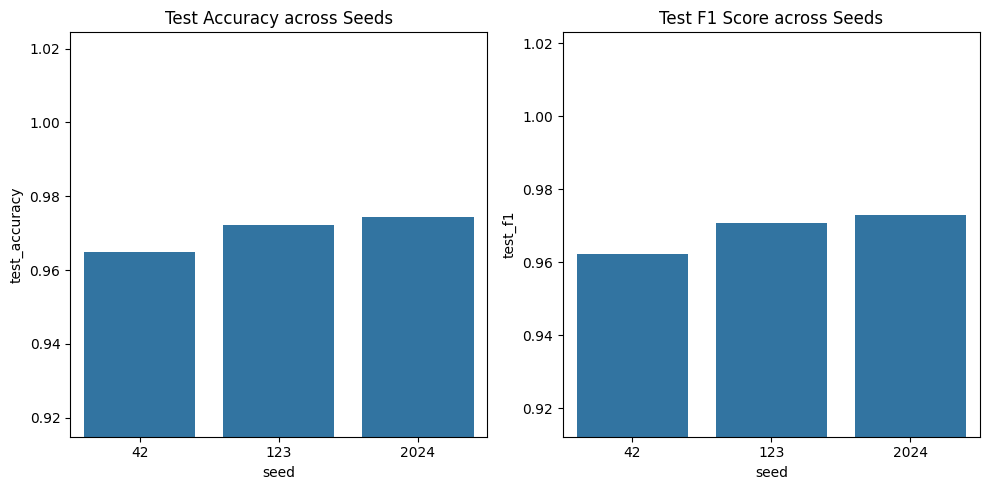

In [9]:
results_df = pd.DataFrame(results)
print('\nSummary Table:')
print(results_df)

# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='seed', y='test_accuracy', data=results_df)
plt.title('Test Accuracy across Seeds')
plt.ylim(results_df['test_accuracy'].min() - 0.05, results_df['test_accuracy'].max() + 0.05)

plt.subplot(1, 2, 2)
sns.barplot(x='seed', y='test_f1', data=results_df)
plt.title('Test F1 Score across Seeds')
plt.ylim(results_df['test_f1'].min() - 0.05, results_df['test_f1'].max() + 0.05)

plt.tight_layout()
plt.show()